<a href="https://colab.research.google.com/github/kk698334/Feature-Engineering-Pipeline-Implementation-and-Performance-Comparison-Experiment/blob/main/Feature_Engineering_Pipeline_Implementation_and_Performance_Comparison_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 필수 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 메시지 무시 (선택 사항, 출력을 깔끔하게 하기 위함)
import warnings
warnings.filterwarnings('ignore')

# 1. 컬럼명 정의 (UCI 원본 데이터는 첫 줄에 컬럼명이 없음)
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 2. 데이터 로드 (URL에서 직접 다운로드)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
# skipinitialspace=True: Adult 데이터셋 특성상 쉼표 뒤에 있는 쓸데없는 공백(" <=50K")을 제거
df = pd.read_csv(url, names=columns, skipinitialspace=True)

# 3. 타겟 변수(income) 이진화 처리 (<=50K는 0, >50K는 1)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# 4. 숨겨진 결측치 '?'를 진짜 결측치(NaN)로 변환
df.replace('?', np.nan, inplace=True)

# 5. 요구사항 출력: 데이터 구조 확인
print("=======================================")
print(f"✅ 데이터 크기 (Shape): {df.shape}")
print(f"✅ 타겟 변수 (income) 고유값: {df['income'].unique()}")
print("=======================================\n")

print("[데이터 기본 구조 파악 (info)]")
df.info()

print("\n[데이터 미리보기]")
display(df.head())

✅ 데이터 크기 (Shape): (32561, 15)
✅ 타겟 변수 (income) 고유값: [0 1]

[데이터 기본 구조 파악 (info)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB

[데이터 미리보기]


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


[결측치 비율 분석 (%)]
occupation        5.660146
workclass         5.638647
native-country    1.790486
dtype: float64
--------------------------------------------------


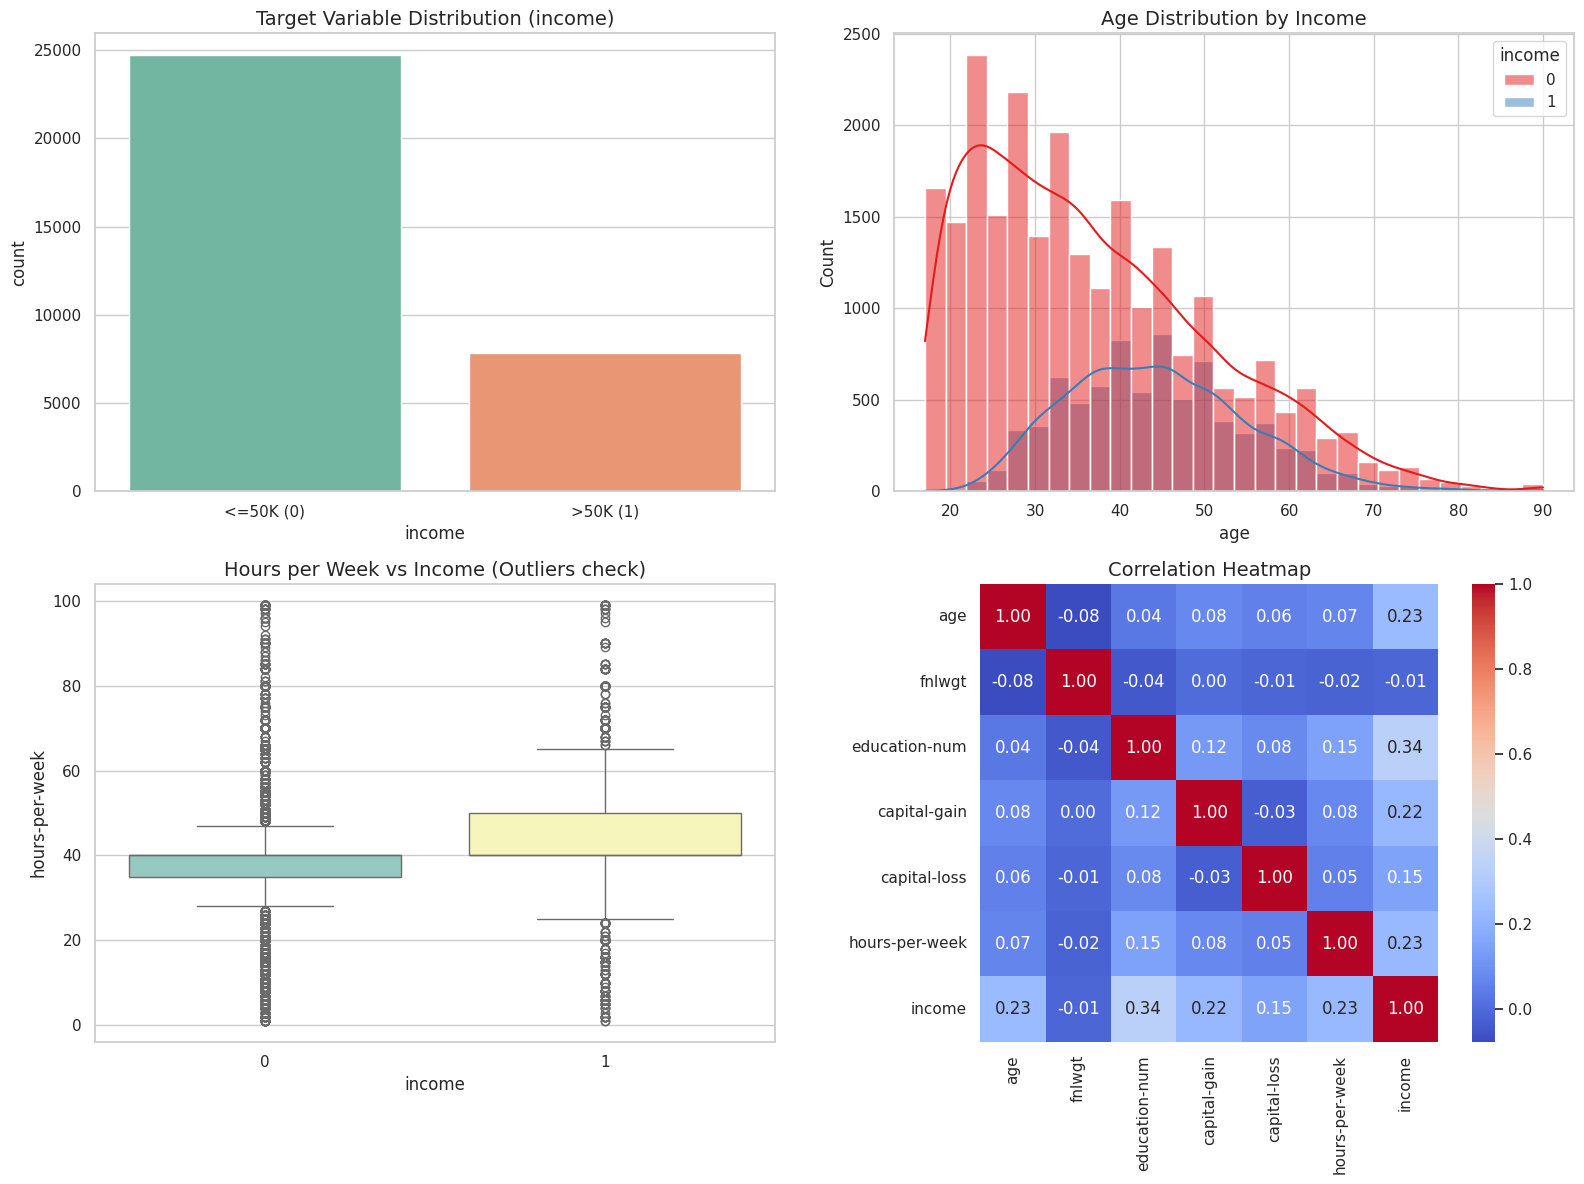

In [ ]:
# STEP 02. 탐색적 데이터 분석 (EDA)

# 1. 결측치 비율 분석
print("[결측치 비율 분석 (%)]")
missing_ratio = df.isnull().sum() / len(df) * 100
print(missing_ratio[missing_ratio > 0].sort_values(ascending=False))
print("-" * 50)

# 시각화 설정 (그래프 크기 및 스타일)
sns.set_theme(style="whitegrid")
#plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 깨짐 방지 (Colab 환경에 따라 나눔고딕 등 폰트 설치가 필요할 수 있음)
#plt.rcParams['axes.unicode_minus'] = False

# 시각화 캔버스 준비 (2x2 배열 형태)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2. 필수 시각화 1: Countplot (타겟 변수 불균형 확인)
sns.countplot(data=df, x='income', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Target Variable Distribution (income)', fontsize=14)
axes[0, 0].set_xticklabels(['<=50K (0)', '>50K (1)'])

# 3. 필수 시각화 2: Histogram (수치형 변수 분포 - 예: 나이)
sns.histplot(data=df, x='age', hue='income', bins=30, kde=True, ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Age Distribution by Income', fontsize=14)

# 4. 필수 시각화 3: Boxplot (이상치 탐색 - 예: 주당 근무시간)
sns.boxplot(data=df, x='income', y='hours-per-week', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Hours per Week vs Income (Outliers check)', fontsize=14)

# 5. 필수 시각화 4: Heatmap (수치형 변수 간 상관관계)
# 수치형 데이터만 선택하여 상관계수 계산
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], square=True)
axes[1, 1].set_title('Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# STEP 3-4. 파생 변수 생성 (필수: 최소 2개 이상)

# 아이디어 1: 순자산 증감 (net_capital) = 자본 이익 - 자본 손실
df['net_capital'] = df['capital-gain'] - df['capital-loss']

# 아이디어 2: 미국인 여부 (is_US)
# 국가 종류가 너무 많으므로 '미국(1)'과 '그 외 국가(0)'로 단순화
# (단, 결측치 NaN은 그대로 둡니다. 나중에 파이프라인에서 채울 예정입니다)
df['is_US'] = df['native-country'].apply(lambda x: 1 if x == 'United States' else (0 if pd.notnull(x) else np.nan))

# 파생 변수를 만들었으니, 중복 의미를 가지는 기존 변수는 제거하여 데이터를 깔끔하게 만듭니다.
df.drop(['capital-gain', 'capital-loss', 'native-country'], axis=1, inplace=True)

print("✅ 파생 변수 2개 생성 완료: 'net_capital', 'is_US'")

# -------------------------------------------------------------------
# 모델 학습을 위한 데이터 분할 (Feature와 Target 나누기)
X = df.drop('income', axis=1)
y = df['income']

# 학습용(Train) 데이터와 테스트용(Test) 데이터 분리 (8:2 비율)
# stratify=y 옵션은 타겟 변수의 불균형 비율을 학습/테스트 세트에도 똑같이 유지해 줍니다. (매우 중요!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ 데이터 분할 완료: 학습용 {X_train.shape[0]}개, 테스트용 {X_test.shape[0]}개")
display(X_train.head(3))

✅ 파생 변수 2개 생성 완료: 'net_capital', 'is_US'
✅ 데이터 분할 완료: 학습용 26048개, 테스트용 6513개


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,net_capital,is_US
15738,32,Private,37210,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,45,0,0.0
27985,43,Private,101950,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,45,0,0.0
30673,20,NaN,122244,HS-grad,9,Never-married,NaN,Not-in-family,White,Female,28,0,0.0


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder

# 1. 변수 타입별로 리스트 분리
# 수치형 변수 (파생변수 net_capital 포함)
numeric_features = ['age', 'fnlwgt', 'education-num', 'hours-per-week', 'net_capital']
# 범주형 변수 (파생변수 is_US 포함)
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'is_US']

# 2. 파이프라인 생성 함수 정의 (다양한 실험 조건을 쉽게 세팅하기 위함)
def get_preprocessor(num_imputer_str, cat_imputer_str, scaler_type, encoder_type):

    # --- 수치형 데이터 파이프라인 ---
    num_steps = []
    if num_imputer_str != 'None':
        num_steps.append(('imputer', SimpleImputer(strategy=num_imputer_str)))

    if scaler_type == 'Standard':
        num_steps.append(('scaler', StandardScaler()))
    elif scaler_type == 'MinMax':
        num_steps.append(('scaler', MinMaxScaler()))
    elif scaler_type == 'Robust':
        num_steps.append(('scaler', RobustScaler()))

    num_transformer = Pipeline(steps=num_steps) if num_steps else 'passthrough'

    # --- 범주형 데이터 파이프라인 ---
    cat_steps = []
    if cat_imputer_str != 'None':
        # 범주형은 주로 최빈값(most_frequent)이나 상수(constant)로 채웁니다.
        cat_steps.append(('imputer', SimpleImputer(strategy=cat_imputer_str)))

    if encoder_type == 'One-Hot':
        cat_steps.append(('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)))
    elif encoder_type == 'Label':
        # Pipeline 내부에서는 2차원 데이터를 처리하는 OrdinalEncoder를 Label Encoding 대용으로 사용합니다.
        cat_steps.append(('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)))

    cat_transformer = Pipeline(steps=cat_steps) if cat_steps else 'passthrough'

    # --- ColumnTransformer로 합치기 ---
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, numeric_features),
            ('cat', cat_transformer, categorical_features)
        ], remainder='passthrough')

    return preprocessor

print("✅ 동적 전처리 파이프라인 생성 함수(get_preprocessor) 정의 완료!")

✅ 동적 전처리 파이프라인 생성 함수(get_preprocessor) 정의 완료!


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import time

# 1. 과제 명세서에 맞춘 4가지 실험 세팅
# 주의: Base 실험의 '없음'은 문자열 데이터로 인한 모델 에러를 방지하기 위해
# 구동이 가능한 최소한의 설정(결측치 채우기 + 라벨인코딩)으로 대체합니다.
experiments = {
    'Base':  {'num_imp': 'median', 'cat_imp': 'most_frequent', 'scale': 'None',     'enc': 'Label',   'fs': False},
    'Exp-1': {'num_imp': 'mean',   'cat_imp': 'most_frequent', 'scale': 'Standard', 'enc': 'One-Hot', 'fs': False},
    'Exp-2': {'num_imp': 'median', 'cat_imp': 'most_frequent', 'scale': 'MinMax',   'enc': 'Label',   'fs': True},
    'Exp-3': {'num_imp': 'most_frequent', 'cat_imp': 'most_frequent', 'scale': 'Robust', 'enc': 'One-Hot', 'fs': True}
}

# 결과를 담을 빈 리스트
results = []

# 2. 모델 정의 (학습 속도가 빠르고 성능이 좋은 LightGBM)
model = LGBMClassifier(random_state=42, verbose=-1)

# 3. 실험 반복 실행 (For Loop)
print("🚀 각 실험별 파이프라인 학습을 시작합니다...\n")

for exp_name, params in experiments.items():
    start_time = time.time()

    # 앞서 만든 함수로 전처리 파이프라인 조립
    preprocessor = get_preprocessor(params['num_imp'], params['cat_imp'], params['scale'], params['enc'])

    # 전체 파이프라인 구성 (전처리 -> [변수 선택] -> 모델)
    steps = [('preprocessor', preprocessor)]

    # Feature Selection이 True(O)인 경우: 통계적 유의미성(f_classif) 기반 상위 10개 변수만 선택
    if params['fs']:
        steps.append(('feature_selection', SelectKBest(score_func=f_classif, k=10)))

    steps.append(('classifier', model))

    # 최종 파이프라인 객체 생성
    pipeline = Pipeline(steps)

    # 4. 모델 학습
    pipeline.fit(X_train, y_train)

    # 5. 예측 및 평가 (가산점 지표인 F1, ROC-AUC 포함)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] # ROC-AUC를 위한 확률값

    results.append({
        'Experiment': exp_name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_pred_proba), 4),
        'Time(s)': round(time.time() - start_time, 2)
    })

    print(f"✅ {exp_name} 학습 완료!")

# 6. 최종 결과표 출력
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("🎯 [최종 성능 비교표]")
print("="*50)
display(results_df)

🚀 각 실험별 파이프라인 학습을 시작합니다...

✅ Base 학습 완료!
✅ Exp-1 학습 완료!
✅ Exp-2 학습 완료!
✅ Exp-3 학습 완료!

🎯 [최종 성능 비교표]


,Experiment,Accuracy,F1-Score,ROC-AUC,Time(s)
0,Base,0.8738,0.7183,0.9307,1.52
1,Exp-1,0.8747,0.7221,0.9293,1.47
2,Exp-2,0.8739,0.7203,0.9294,2.13
3,Exp-3,0.8331,0.6263,0.8851,1.94



🚀 SHAP 분석을 위한 모델 학습 시작...


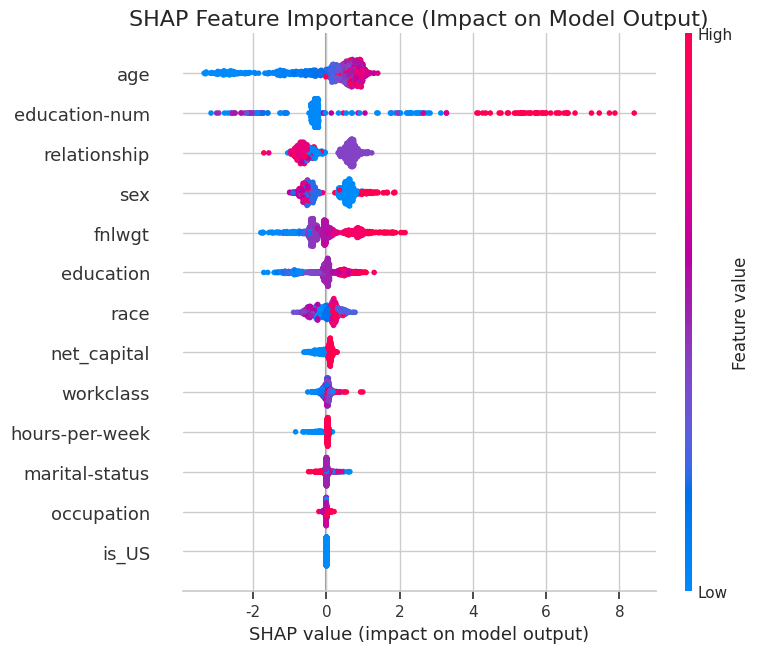

In [ ]:
# 1. SHAP 라이브러리 설치 (Colab에 없을 수 있으므로 설치 진행)
!pip install shap

import shap
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

print("\n🚀 SHAP 분석을 위한 모델 학습 시작...")

# 2. 파이프라인 대신 명시적인 전처리 적용
# (SHAP은 파이프라인 내부를 투시하기 어려워, 변수명을 살리기 위해 데이터를 직접 변환합니다.)
# Exp-2 세팅: 숫자형은 MinMax, 범주형은 Label Encoding 적용
preprocessor_shap = get_preprocessor('median', 'most_frequent', 'MinMax', 'Label')

X_train_trans = preprocessor_shap.fit_transform(X_train)
X_test_trans = preprocessor_shap.transform(X_test)

# 3. 모델 학습
model_shap = LGBMClassifier(random_state=42, verbose=-1)
model_shap.fit(X_train_trans, y_train)

# 4. SHAP Explainer 객체 생성 및 SHAP Value 계산
explainer = shap.TreeExplainer(model_shap)
# 계산 속도를 위해 테스트 데이터 중 1,000개만 샘플링하여 시각화합니다.
X_test_sample = X_test_trans[:1000]
shap_values = explainer.shap_values(X_test_sample)

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (Impact on Model Output)", fontsize=16)

# LightGBM의 경우 shap_values가 리스트 형태([Class 0, Class 1])로 나올 수 있으므로 처리
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_sample, feature_names=X.columns)
else:
    shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)